## Extracción de Datos

In [9]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# Configurar cliente con caché y reintentos
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 7.9,
    "longitude": -72.5,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "rain",
    ],
    "timezone": "America/Bogota",
    "past_days": 5,
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

print(f"Coordenadas: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevación: {response.Elevation()} m snm")
print(f"Offset UTC: {response.UtcOffsetSeconds()}s")

# Procesar variables horarias — el índice debe coincidir con el orden en `hourly`
hourly = response.Hourly()
hourly_temperature_2m      = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity   = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation       = hourly.Variables(2).ValuesAsNumpy()
hourly_rain                = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left",
    ),
    "temperature_2m": hourly_temperature_2m,
    "relative_humidity_2m": hourly_relative_humidity,
    "precipitation": hourly_precipitation,
    "rain": hourly_rain
}

df = pd.DataFrame(data=hourly_data)
print("\nDatos horarios\n", df)

Coordenadas: 7.90861177444458°N -72.49148559570312°E
Elevación: 299.0 m snm
Offset UTC: -18000s

Datos horarios
                          date  temperature_2m  relative_humidity_2m  \
0   2026-05-01 05:00:00+00:00       24.350000             85.183945   
1   2026-05-01 06:00:00+00:00       24.350000             86.758438   
2   2026-05-01 07:00:00+00:00       24.750000             84.449104   
3   2026-05-01 08:00:00+00:00       24.549999             83.913223   
4   2026-05-01 09:00:00+00:00       24.350000             84.406136   
..                        ...             ...                   ...   
283 2026-05-13 00:00:00+00:00       28.299999             59.093754   
284 2026-05-13 01:00:00+00:00       27.650000             61.759216   
285 2026-05-13 02:00:00+00:00       27.000000             64.556404   
286 2026-05-13 03:00:00+00:00       26.350000             67.701790   
287 2026-05-13 04:00:00+00:00       25.799999             70.374939   

     precipitation  rain  
0      

In [11]:
df_bogota=df.copy()
df_bogota["date"] = df_bogota["date"].dt.tz_convert("America/Bogota")
df_bogota

,date,temperature_2m,relative_humidity_2m,precipitation,rain
0,2026-05-01 00:00:00-05:00,24.350000,85.183945,0.0,0.0
1,2026-05-01 01:00:00-05:00,24.350000,86.758438,0.0,0.0
2,2026-05-01 02:00:00-05:00,24.750000,84.449104,0.0,0.0
3,2026-05-01 03:00:00-05:00,24.549999,83.913223,0.0,0.0
4,2026-05-01 04:00:00-05:00,24.350000,84.406136,0.0,0.0
...,...,...,...,...,...
283,2026-05-12 19:00:00-05:00,28.299999,59.093754,0.0,0.0
284,2026-05-12 20:00:00-05:00,27.650000,61.759216,0.0,0.0
285,2026-05-12 21:00:00-05:00,27.000000,64.556404,0.0,0.0
286,2026-05-12 22:00:00-05:00,26.350000,67.701790,0.0,0.0


In [12]:
# ✅ Versión limpia y directa
df_bogota["hour"] = df_bogota["date"].dt.hour 
df_bogota["date"] = df_bogota["date"].dt.normalize().dt.tz_localize(None)
df_bogota = df_bogota[["date", "hour", "temperature_2m", "relative_humidity_2m", "precipitation", "rain"]]
df_bogota

,date,hour,temperature_2m,relative_humidity_2m,precipitation,rain
0,2026-05-01,0,24.350000,85.183945,0.0,0.0
1,2026-05-01,1,24.350000,86.758438,0.0,0.0
2,2026-05-01,2,24.750000,84.449104,0.0,0.0
3,2026-05-01,3,24.549999,83.913223,0.0,0.0
4,2026-05-01,4,24.350000,84.406136,0.0,0.0
...,...,...,...,...,...,...
283,2026-05-12,19,28.299999,59.093754,0.0,0.0
284,2026-05-12,20,27.650000,61.759216,0.0,0.0
285,2026-05-12,21,27.000000,64.556404,0.0,0.0
286,2026-05-12,22,26.350000,67.701790,0.0,0.0


### Verificación de los datos

In [13]:
# hay datos nulos
df_bogota.isnull().sum()

date                    0
hour                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
dtype: int64

## Análisis básico

In [14]:
# ¿Cuál es la temperatura promedio?
temperatura_promedio=df_bogota["temperature_2m"].mean()
display(temperatura_promedio)

np.float32(27.629862)

In [15]:
# ¿Cuándo llueve más?
# ¿a qué hora llueve más en promedio?
lluvia_por_hora = df_bogota.groupby("hour")["rain"].mean().sort_values()
display(lluvia_por_hora.head(5))
# ¿qué día llovió más?
lluvia_por_dia = df_bogota.groupby("date")["rain"].sum().sort_values()
display(lluvia_por_dia.head(5))

# El momento exacto de mayor lluvia
idx = df_bogota["rain"].idxmax()
print(df_bogota.loc[idx, ["date", "hour", "rain"]])


hour
0    0.0
1    0.0
2    0.0
5    0.0
7    0.0
Name: rain, dtype: float32

date
2026-05-01    0.0
2026-05-03    0.0
2026-05-06    0.0
2026-05-05    0.0
2026-05-08    0.0
Name: rain, dtype: float32

date    2026-05-02 00:00:00
hour                     14
rain                    0.3
Name: 38, dtype: object


In [16]:
df_bogota.info()

<class 'pandas.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype        
---  ------                --------------  -----        
 0   date                  288 non-null    datetime64[s]
 1   hour                  288 non-null    int32        
 2   temperature_2m        288 non-null    float32      
 3   relative_humidity_2m  288 non-null    float32      
 4   precipitation         288 non-null    float32      
 5   rain                  288 non-null    float32      
dtypes: datetime64[s](1), float32(4), int32(1)
memory usage: 8.0 KB


In [17]:
# Matriz limpia, sin redundancia
df_bogota.corr()

,date,hour,temperature_2m,relative_humidity_2m,precipitation,rain
date,1.000000e+00,1.184008e-13,0.081873,-0.306091,-0.017260,-0.114704
hour,1.184008e-13,1.000000e+00,0.382879,-0.255443,0.043038,0.001300
temperature_2m,8.187319e-02,3.828789e-01,1.000000,-0.920104,0.054303,-0.075317
relative_humidity_2m,-3.060905e-01,-2.554432e-01,-0.920104,1.000000,-0.001960,0.126477
precipitation,-1.726031e-02,4.303807e-02,0.054303,-0.001960,1.000000,0.418994
rain,-1.147036e-01,1.300046e-03,-0.075317,0.126477,0.418994,1.000000


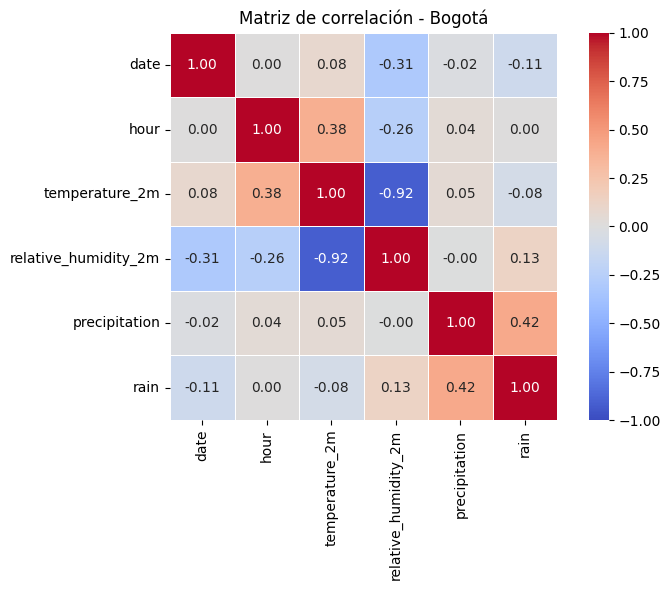

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_bogota.corr(),
    annot=True,        # muestra los valores
    fmt=".2f",         # 2 decimales
    cmap="coolwarm",   # rojo=positivo, azul=negativo
    vmin=-1, vmax=1,   # escala fija
    square=True,
    linewidths=0.5
)
plt.title("Matriz de correlación - Bogotá")
plt.tight_layout()
plt.show()